# 02 — Main sweep: feature × model × (scheme, policy)

For every combination of

- buyer scheme ∈ {A, B, C, D}
- seller policy ∈ {PVD, IC, FRB, RFK, OADS, MEVJ}
- feature family ∈ {Base, I, II, III, IV, V, VI, VII}
- model ∈ {Base, OLS, Ridge-λ, GBR}    (MLP dropped on user request)

this notebook fits the model on D_negotiation by grouped 10-fold CV (folds at run_id), records the four paper metrics (MAE, MAE\$, MAPE, MAPE\$), and runs the two-stage selection rule from §B.1.

The sweep is parallelised over (scheme, policy) with `ProcessPoolExecutor`. On a 2-core machine expect roughly 12–15 minutes for the full sweep; pass `--workers` higher if you have more cores.

In [1]:
import os, sys, time, warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import negolin_v15 as nv
from run_analysis import build_leaderboard_for_group

DATA_DIR = 'merged_results'
OUT_DIR  = './out'
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Sweep — parallel over (scheme, policy)

Each worker reloads only the JSONs it needs (one scheme × one policy = 5 vehicle files), so memory stays bounded.

If something crashes mid-sweep, set `RESUME = True` and the cell will skip any (scheme, policy) already in `out/leaderboard_full.csv`.

In [4]:
t0 = time.time()

print("Loading all raw data once...")
raw = nv.load_run_files(DATA_DIR, schemes=nv.SCHEMES, policies=nv.POLICIES)

print(f"Raw loading done: {time.time() - t0:.1f}s")

print("Preprocessing all turns once...")
_, all_turns = nv.preprocess_turns(raw)

print(f"Preprocessing done: {time.time() - t0:.1f}s")

parts = []

for s in nv.SCHEMES:
    for p in nv.POLICIES:
        turns = all_turns[
            (all_turns["scheme"] == s) &
            (all_turns["policy"] == p)
        ].copy()

        lb = build_leaderboard_for_group(turns, s, p)
        parts.append(lb)

        print(f"  {s}/{p} rows={len(lb)} wall={time.time() - t0:.1f}s")

leaderboard = (
    pd.concat(parts, ignore_index=True)
    .drop_duplicates(subset=["scheme", "policy", "family", "model"], keep="last")
    .reset_index(drop=True)
)

leaderboard.to_csv(os.path.join(OUT_DIR, "leaderboard_full.csv"), index=False)
leaderboard.head()

Loading all raw data once...
Raw loading done: 1.3s
Preprocessing all turns once...
Preprocessing done: 1.3s
  A/PVD rows=22 wall=23.4s
  A/IC rows=22 wall=44.9s
  A/FRB rows=22 wall=67.9s
  A/RFK rows=22 wall=91.4s
  A/OADS rows=22 wall=112.3s
  A/MEVJ rows=22 wall=133.3s
  B/PVD rows=22 wall=161.0s
  B/IC rows=22 wall=183.9s
  B/FRB rows=22 wall=207.9s
  B/RFK rows=22 wall=232.7s
  B/OADS rows=22 wall=257.9s
  B/MEVJ rows=22 wall=285.2s
  C/PVD rows=22 wall=306.3s
  C/IC rows=22 wall=327.6s
  C/FRB rows=22 wall=355.2s
  C/RFK rows=22 wall=375.8s
  C/OADS rows=22 wall=400.6s
  C/MEVJ rows=22 wall=424.9s
  D/PVD rows=22 wall=446.7s
  D/IC rows=22 wall=466.4s
  D/FRB rows=22 wall=487.5s
  D/RFK rows=22 wall=507.6s
  D/OADS rows=22 wall=528.7s
  D/MEVJ rows=22 wall=550.1s


,scheme,policy,family,model,n,n_full,frac_neg,mae,mae_se,mae_dollar,mape,mape_dollar,bias,rmse,dim_phi,tau,theta_l1,alpha_med,elapsed_s
0,A,PVD,Base,Base,1041,1508,0.690318,0.634023,0.053073,544.675741,1.859767,0.695624,-0.238212,1.273981,2,1,NaN,NaN,0.014443
1,A,PVD,I,OLS,1041,1508,0.690318,0.396704,0.026567,602.740928,1.646181,0.622099,0.000093,0.791807,4,1,2.304259,NaN,0.021994
2,A,PVD,I,Ridge,1041,1508,0.690318,0.395884,0.026501,601.238165,1.641829,0.622892,0.000065,0.791803,4,1,1.065247,10.0,0.388020
3,A,PVD,I,GBR,1041,1508,0.690318,0.371476,0.025930,421.478435,1.179438,0.396444,-0.024292,0.728933,4,1,NaN,NaN,2.810714
4,A,PVD,II,OLS,1041,1508,0.690318,0.391105,0.025588,561.095496,1.519003,0.621369,-0.000016,0.781912,4,1,0.854512,NaN,0.020000


## 2. Per-(scheme, policy) leaderboards

In [5]:
# Best model per (scheme, policy) by Y-scale MAE
best = (leaderboard.sort_values('mae')
        .groupby(['scheme','policy'], as_index=False).first()[
            ['scheme','policy','family','model','mae','mae_se','mae_dollar','mape','dim_phi','tau','theta_l1']])
best = best.sort_values(['scheme','policy']).reset_index(drop=True)
best.round(4)

,scheme,policy,family,model,mae,mae_se,mae_dollar,mape,dim_phi,tau,theta_l1
0,A,FRB,VII,GBR,0.6954,0.0376,333.8034,1.0490,7,2,2.0545
1,A,IC,IV,GBR,0.5756,0.0204,386.2132,1.0855,6,1,1.5336
2,A,MEVJ,V,GBR,0.4057,0.0295,447.0595,1.2948,3,1,1.3190
3,A,OADS,VII,GBR,0.6647,0.0369,375.9878,1.0508,7,2,1.7963
4,A,PVD,IV,GBR,0.3664,0.0249,418.1937,1.1489,6,1,1.0660
5,A,RFK,III,GBR,0.4834,0.0298,394.9133,1.2957,6,2,1.5844
6,B,FRB,II,GBR,0.6559,0.0244,276.8098,0.8502,4,1,1.8924
7,B,IC,III,GBR,0.7511,0.0359,320.7657,0.9858,6,2,1.9831
8,B,MEVJ,VII,GBR,0.3992,0.0111,274.8711,0.7370,7,2,1.4473
9,B,OADS,III,GBR,0.6343,0.0506,327.5761,0.8907,6,2,1.8738


## 3. Stage 1 + Stage 2 selection (the 'most parsimonious linear spec' table)

In [6]:
selected = []
for (sch, pol), lb in leaderboard.groupby(['scheme','policy']):
    res = nv.stage_selection(lb.dropna(subset=['mae']))
    selected.append({
        'scheme': sch, 'policy': pol,
        'best_family':  res['best_row']['family'],
        'best_model':   res['best_row']['model'],
        'best_mae':     res['best_row']['mae'],
        'best_mae$':    res['best_row']['mae_dollar'],
        'chosen_family':  res['chosen_row']['family'],
        'chosen_model':   res['chosen_row']['model'],
        'chosen_dim_phi': res['chosen_row']['dim_phi'],
        'chosen_tau':     res['chosen_row']['tau'],
        'chosen_theta_l1':res['chosen_row']['theta_l1'],
        'chosen_mae':     res['chosen_row']['mae'],
        'chosen_mae$':    res['chosen_row']['mae_dollar'],
        'gap_rel':        res['gap_mae_rel'],
    })
selected = pd.DataFrame(selected).sort_values(['scheme','policy']).reset_index(drop=True)
selected.to_csv(os.path.join(OUT_DIR, 'selected_linear.csv'), index=False)
selected.round(4)

,scheme,policy,best_family,best_model,best_mae,best_mae$,chosen_family,chosen_model,chosen_dim_phi,chosen_tau,chosen_theta_l1,chosen_mae,chosen_mae$,gap_rel
0,A,FRB,VII,GBR,0.6954,333.8034,VII,GBR,7,2,NaN,0.6954,333.8034,0.0000
1,A,IC,IV,GBR,0.5756,386.2132,IV,GBR,6,1,NaN,0.5756,386.2132,0.0000
2,A,MEVJ,V,GBR,0.4057,447.0595,V,GBR,3,1,NaN,0.4057,447.0595,0.0000
3,A,OADS,VII,GBR,0.6647,375.9878,VII,GBR,7,2,NaN,0.6647,375.9878,0.0000
4,A,PVD,IV,GBR,0.3664,418.1937,V,OLS,3,1,0.7226,0.3899,562.5097,0.0640
5,A,RFK,III,GBR,0.4834,394.9133,III,GBR,6,2,NaN,0.4834,394.9133,0.0000
6,B,FRB,II,GBR,0.6559,276.8098,II,GBR,4,1,NaN,0.6559,276.8098,0.0000
7,B,IC,III,GBR,0.7511,320.7657,III,GBR,6,2,NaN,0.7511,320.7657,0.0000
8,B,MEVJ,VII,GBR,0.3992,274.8711,VII,GBR,7,2,NaN,0.3992,274.8711,0.0000
9,B,OADS,III,GBR,0.6343,327.5761,VI,OLS,4,2,1.6258,0.6812,393.1901,0.0741


**Reading the table.** `chosen_*` is the most parsimonious *linear* specification within ~1 SE of the best model overall (where 'best' is by Y-scale MAE). `gap_rel` is the relative gap in MAE between this chosen linear model and the absolute best model — small numbers (say < 0.05) mean a linear policy explains essentially as much as the most flexible model we tried, which is the central claim of §2.2.

## 4. Heatmaps: best linear MAE across (scheme, policy)

In [7]:
linear_only = leaderboard.query("model == 'OLS' or model.str.startswith('Ridge')")
best_linear = linear_only.sort_values('mae').groupby(['scheme','policy','family'], as_index=False).first()
piv = best_linear.pivot_table(index=['policy','family'], columns='scheme', values='mae')
piv = piv.reindex(index=pd.MultiIndex.from_product([list(nv.POLICIES), list(nv.FEATURE_SPECS.keys())],
                                                    names=['policy','family']))
piv.round(3)

scheme             A      B      C      D
policy family                            
PVD    I       0.396  0.419  0.201  0.253
       II      0.390  0.397  0.185  0.249
       III     0.382  0.368  0.179  0.238
       IV      0.391  0.396  0.185  0.247
       V       0.389  0.401  0.192  0.255
       VI      0.381  0.366  0.181  0.238
       VII     0.385  0.368  0.176  0.233
IC     I       0.685  0.889  0.602  0.696
       II      0.653  0.857  0.565  0.667
       III     0.652  0.847  0.558  0.668
       IV      0.655  0.851  0.563  0.664
       V       0.651  0.855  0.551  0.672
       VI      0.650  0.844  0.539  0.672
       VII     0.654  0.845  0.553  0.668
FRB    I       0.800  0.732  0.475  0.614
       II      0.762  0.719  0.435  0.591
       III     0.748  0.699  0.427  0.593
       IV      0.763  0.711  0.436  0.590
       V       0.768  0.719  0.426  0.588
       VI      0.747  0.697  0.414  0.590
       VII     0.745  0.695  0.427  0.590
RFK    I       0.543  0.837  0.399  0.646
       II      0.529  0.801  0.374  0.604
       III     0.520  0.780  0.354  0.602
       IV      0.522  0.793  0.372  0.602
       V       0.532  0.800  0.368  0.605
       VI      0.526  0.777  0.353  0.594
       VII     0.526  0.775  0.353  0.592
OADS   I       0.797  0.747  0.340  0.490
       II      0.744  0.700  0.325  0.480
       III     0.739  0.683  0.315  0.480
       IV      0.742  0.700  0.327  0.476
       V       0.745  0.701  0.325  0.489
       VI      0.738  0.681  0.315  0.480
       VII     0.741  0.682  0.315  0.474
MEVJ   I       0.494  0.512  0.224  0.319
       II      0.482  0.480  0.211  0.312
       III     0.470  0.458  0.191  0.306
       IV      0.483  0.475  0.209  0.313
       V       0.480  0.478  0.210  0.323
       VI      0.470  0.455  0.192  0.312
       VII     0.474  0.455  0.191  0.308

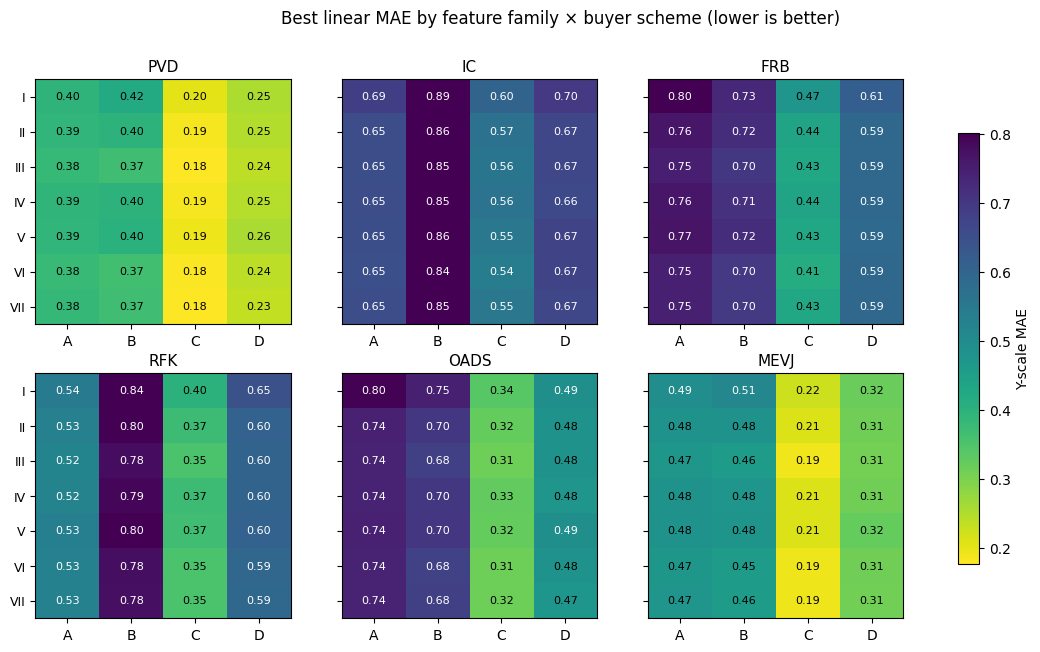

In [8]:
# 6 panels (one per policy), each shows family × scheme MAE
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
families = list(nv.FEATURE_SPECS.keys())
vmin = float(linear_only.mae.min())
vmax = float(linear_only.mae.quantile(0.95))

for ax, pol in zip(axes.ravel(), nv.POLICIES):
    sub = best_linear.query('policy == @pol').pivot_table(
        index='family', columns='scheme', values='mae').reindex(index=families)
    im = ax.imshow(sub.values, aspect='auto', cmap='viridis_r', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(sub.columns))); ax.set_xticklabels(sub.columns)
    ax.set_yticks(range(len(families)));    ax.set_yticklabels(families, fontsize=9)
    ax.set_title(pol, fontsize=11)
    for i, fam in enumerate(families):
        for j, sc in enumerate(sub.columns):
            v = sub.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                        color='white' if v > (vmin+vmax)/2 else 'black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Y-scale MAE')
fig.suptitle('Best linear MAE by feature family × buyer scheme (lower is better)', fontsize=12)
fig.savefig(os.path.join(OUT_DIR, 'fig_mae_heatmap.png'), dpi=130, bbox_inches='tight')
plt.show()

## 5. How big is the linear-vs-best gap?

For each (scheme, policy) compare the chosen linear model's MAE to the overall best (typically GBR).

In [9]:
gaps = selected[['scheme','policy','chosen_mae','best_mae','gap_rel']].copy()
gaps['gap_pp'] = (gaps['gap_rel'] * 100).round(2)
gaps_pivot = gaps.pivot(index='policy', columns='scheme', values='gap_pp')
print('Relative gap (linear chosen vs absolute best), in % of best MAE:')
display(gaps_pivot.round(2))

# Also: dollar-scale comparison
gaps_dollar = selected[['scheme','policy','chosen_mae$','best_mae$']].copy()
gaps_dollar['gap_dollar'] = gaps_dollar['chosen_mae$'] - gaps_dollar['best_mae$']
gaps_dollar.pivot(index='policy', columns='scheme', values='gap_dollar').round(1)

Relative gap (linear chosen vs absolute best), in % of best MAE:


scheme,A,B,C,D
policy,,,,
FRB,0.0,0.00,5.26,0.00
IC,0.0,0.00,0.00,0.00
MEVJ,0.0,0.00,0.00,6.87
OADS,0.0,7.41,0.00,0.00
PVD,6.4,0.00,0.00,7.46
RFK,0.0,0.00,0.00,0.00


scheme,A,B,C,D
policy,,,,
FRB,0.0,0.0,48.5,0.0
IC,0.0,0.0,0.0,0.0
MEVJ,0.0,0.0,0.0,92.5
OADS,0.0,65.6,0.0,0.0
PVD,144.3,0.0,0.0,42.6
RFK,0.0,0.0,0.0,0.0


If the per-cell gaps are typically a small percentage on the Y-scale, the central claim holds: **prompted seller behaviour can be effectively captured by a low-dimensional linear policy on the logit-increment scale.** The dollar-scale gap is a separate read and tends to be larger — that's the sigmoid-inversion effect from notebook 1.